In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


In [2]:
recording='04_Funk1-114-Ab_comp'
 
hex_audiofile_dir='/home/gerald/Documents/GuitarMidi-research/guitarset/audio_hex-pickup_debleeded/'
# hex_file='00_BN1-129-Eb_solo_hex_cln.wav'
hex_file=hex_audiofile_dir+recording+'_hex_cln.wav'

mix_audiofile_dir='/home/gerald/Documents/GuitarMidi-research/guitarset/audio_mono-pickup_mix/'
mix_audiofile=mix_audiofile_dir+recording+'_mix.wav'



# Load the audio file
y, sr = librosa.load(hex_file,sr=None,mono=False)
ymix, sr = librosa.load(mix_audiofile,sr=None,mono=False)

6


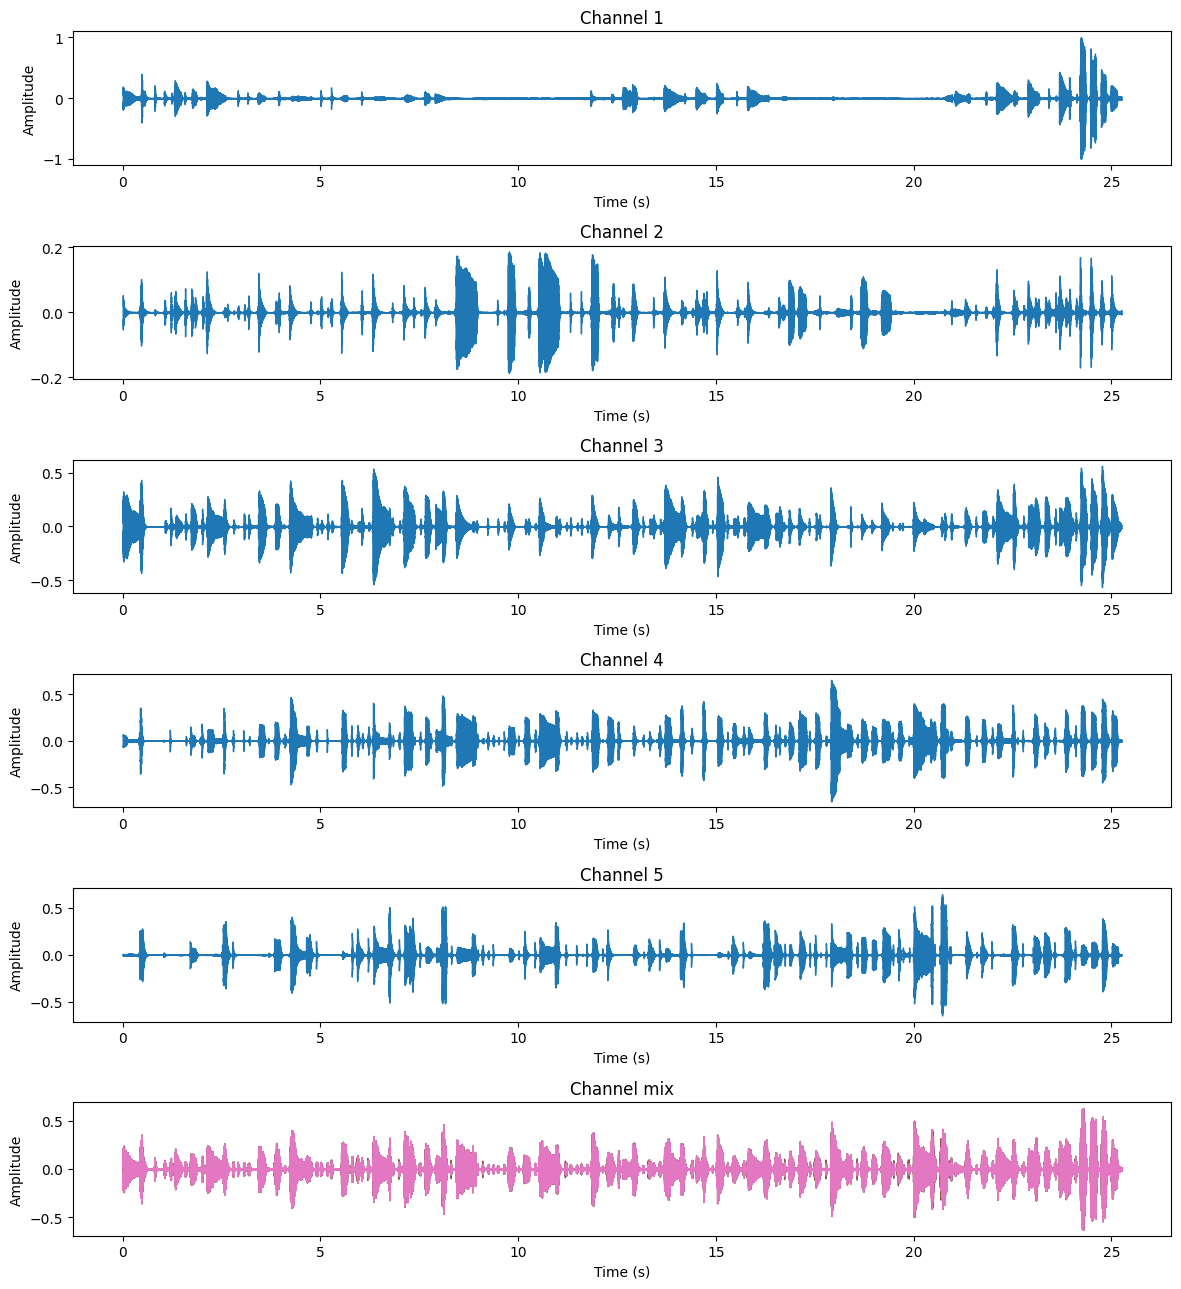

In [3]:

# Check the number of channels
num_channels = y.shape[0] if y.ndim > 1 else 1


print(num_channels)

# Plot each channel
plt.figure(figsize=(12, 2 * num_channels+1))

for channel in range(num_channels):
    plt.subplot(num_channels, 1, channel + 1)
    librosa.display.waveshow(y[channel,:], sr=sr)
    plt.title(f'Channel {channel + 1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    plt.subplot(num_channels, 1, num_channels)
    librosa.display.waveshow(ymix[:], sr=sr)
    plt.title(f'Channel mix')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [4]:
import ipywidgets as widgets
import sounddevice as sd #conda install -c conda-forge portaudio

from IPython.display import display
# Create a dropdown widget to select the channel
channel_selector = widgets.Dropdown(
    options=[(f'Channel {i+1}', i) for i in range(num_channels)],
    value=0,
    description='Channel:',
)


# Create a button to play the selected channel
play_button = widgets.Button(description="Play")

play_mix_button = widgets.Button(description="Play Mix")

# Function to play the selected channel
def play_channel(b):
    channel = channel_selector.value
    print(f'Playing Channel {channel + 1}')
    sd.play(y[channel,:], samplerate=sr)
    sd.wait()
    
# Function to play the selected channel
def play_mix(b):
    print(f'Playing Mix')
    sd.play(ymix[:], samplerate=sr)
    sd.wait()

# Attach the function to the button
play_button.on_click(play_channel)

# Attach the function to the button
play_mix_button.on_click(play_mix)

# Display the widgets
display(channel_selector, play_button,play_mix_button)

Dropdown(description='Channel:', options=(('Channel 1', 0), ('Channel 2', 1), ('Channel 3', 2), ('Channel 4', …

Button(description='Play', style=ButtonStyle())

Button(description='Play Mix', style=ButtonStyle())

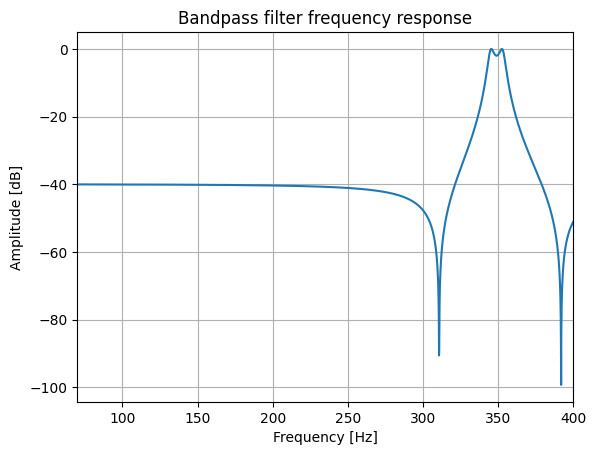

In [5]:
from scipy import signal


# Define filter specifications
center_frequency = 349  # Center frequency in Hz
bandwidth = 10  # Bandwidth in Hz

# Calculate the lower and upper cutoff frequencies
lower_cutoff = center_frequency - bandwidth / 2
upper_cutoff = center_frequency + bandwidth / 2

# Sampling frequency
fs = 48000  # Sampling frequency in Hz

# Normalize the cutoff frequencies with respect to the Nyquist frequency
nyquist = fs / 2
low = lower_cutoff / nyquist
high = upper_cutoff / nyquist

# Design the bandpass filter


b,a=signal.ellip(N=2,rp=2,rs=40.0,Wn=[low,high],btype='bandpass',analog=False)

# Frequency response
w, h = signal.freqz(b, a, worN=200000, fs=fs)

# Plot the frequency response
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Bandpass filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.xlim(70, 400)  # Limit the x-axis to focus around the center frequency
plt.grid()
plt.show()


-0.05807495
-0.0057820892645124135


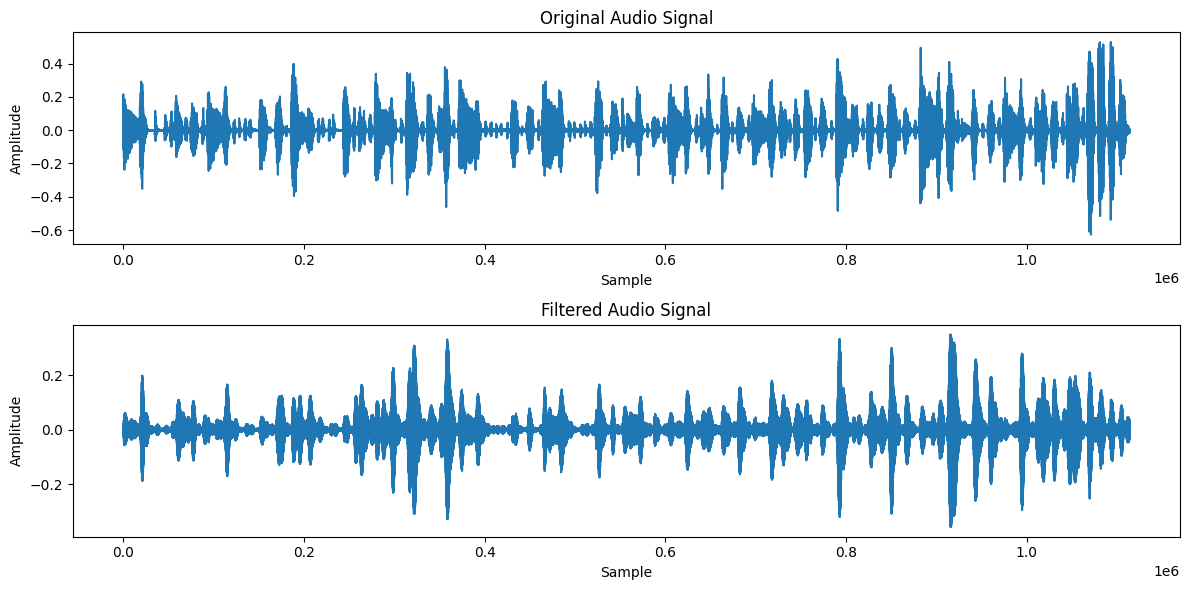

In [6]:
import sounddevice as sd #conda install -c conda-forge portaudio

filtered_ymix=10*signal.lfilter(b,a,ymix[:])

print(ymix[10])
print(filtered_ymix[10])

# Plot the original and filtered signals (optional)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ymix)
plt.title('Original Audio Signal')
plt.xlabel('Sample')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(filtered_ymix[:])
plt.title('Filtered Audio Signal')
plt.xlabel('Sample')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Play the filtered audio signal
sd.play(filtered_ymix[:], samplerate=sr)
sd.wait()  # Wait until the audio is finished playing
